**IMPORT LIBRARIES AND LOAD DATASET**

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
try:
    df_transactions = pd.read_csv('train_transactions.csv')
except FileNotFoundError:
    print("train_transactions.csv not found in the current directory. Trying sample_data...")
    try:
        df_transactions = pd.read_csv('/content/train_transactions.csv')
    except FileNotFoundError:
        print("train_transactions.csv not found in /content/sample_data either. Please provide the correct path.")
        # Exit or raise an error if the file is not found in common locations
        # For now, let's assume it might be directly uploaded to content/
        df_transactions = None


if df_transactions is not None:
    print("\n--- First 5 rows of train_transactions.csv ---")
    display(df_transactions.head())



--- First 5 rows of train_transactions.csv ---


,transaction_id,cardholder_id,merchant_id,merchant_category,transaction_timestamp,transaction_hour,transaction_day_of_week,transaction_amount_inr,country_code,is_international,pos_entry_mode,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,credit_limit_inr,is_fraud
0,TXN00012767,CH_004461,MER_00389,restaurant,2023-10-28 08:59:47,8,5,291.07,IN,0,CNP,2,2,67.88,385.43,178.6,1417,50000,0
1,TXN00046769,CH_005639,MER_00196,restaurant,2023-09-08 23:56:49,23,4,221.33,IN,0,SWIPE,3,4,49.88,322.25,184.1,1792,200000,0
2,TXN00046574,CH_000863,MER_00454,utilities,2023-09-26 21:01:05,21,1,231.06,IN,0,CHIP,3,2,31.52,369.70,127.6,859,75000,0
3,TXN00020038,CH_005930,MER_00391,healthcare,2023-04-11 23:06:34,23,1,211.16,IN,0,CHIP,1,1,134.10,376.04,196.4,1491,50000,0
4,TXN00002610,CH_006182,MER_00157,healthcare,2023-09-20 19:31:44,19,2,139.86,IN,0,CHIP,3,2,119.01,132.11,43.6,347,150000,0


In [ ]:
if df_transactions is not None:
    print("\n--- DataFrame Info ---")
    df_transactions.info()



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           15000 non-null  object 
 1   cardholder_id            15000 non-null  object 
 2   merchant_id              15000 non-null  object 
 3   merchant_category        15000 non-null  object 
 4   transaction_timestamp    15000 non-null  object 
 5   transaction_hour         15000 non-null  int64  
 6   transaction_day_of_week  15000 non-null  int64  
 7   transaction_amount_inr   15000 non-null  float64
 8   country_code             15000 non-null  object 
 9   is_international         15000 non-null  int64  
 10  pos_entry_mode           15000 non-null  object 
 11  velocity_last_1h         15000 non-null  int64  
 12  velocity_last_24h        15000 non-null  int64  
 13  avg_txn_amount_30d       15000 non-null  float64
 14

In [ ]:
df_transactions['is_fraud'].value_counts(normalize=True)

,proportion
is_fraud,
0,0.9822
1,0.0178


**PERFORM EDA**


--- Class Distribution (Count) ---


,count
is_fraud,
0,14733
1,267



--- Class Distribution (Percentage) ---


,proportion
is_fraud,
0,0.9822
1,0.0178


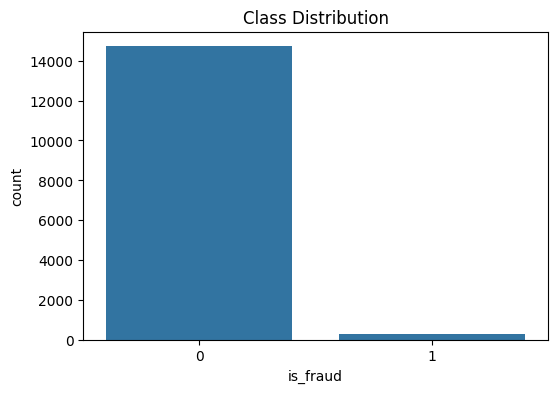

In [ ]:
if df_transactions is not None:
    #Class Distribution
    # Count
    print("\n--- Class Distribution (Count) ---")
    display(df_transactions['is_fraud'].value_counts())

    # Percentage
    print("\n--- Class Distribution (Percentage) ---")
    display(df_transactions['is_fraud'].value_counts(normalize=True))

    # Plot
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(6, 4))
    sns.countplot(x='is_fraud', data=df_transactions)
    plt.title("Class Distribution")
    plt.show()
else:
    print("df_transactions is None. Please ensure 'train_transactions.csv' is loaded correctly.")

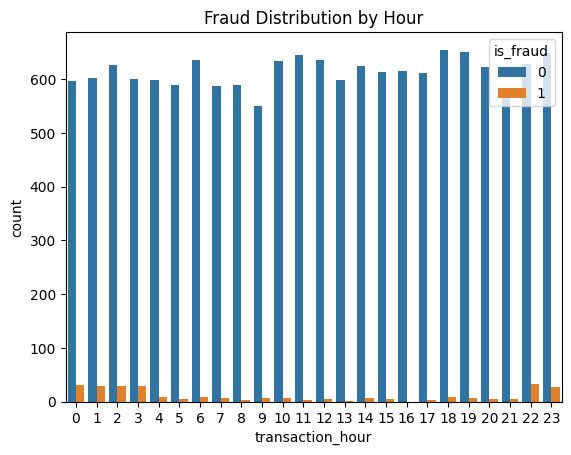

In [ ]:
#Fraud by Hour
sns.countplot(x='transaction_hour', hue='is_fraud', data=df_transactions)
plt.title("Fraud Distribution by Hour")
plt.show()

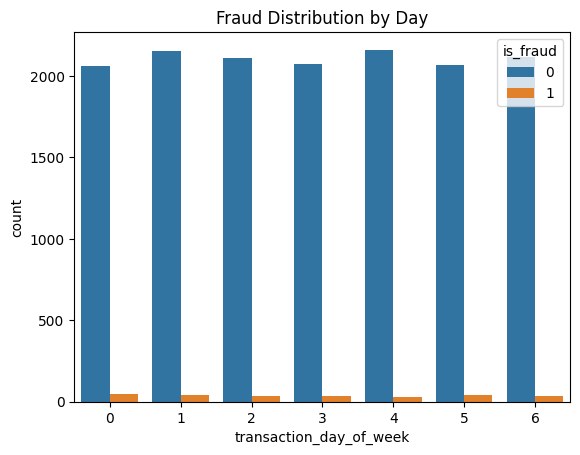

In [ ]:
#Fraud by Day of Week
sns.countplot(x='transaction_day_of_week', hue='is_fraud', data=df_transactions)
plt.title("Fraud Distribution by Day")
plt.show()

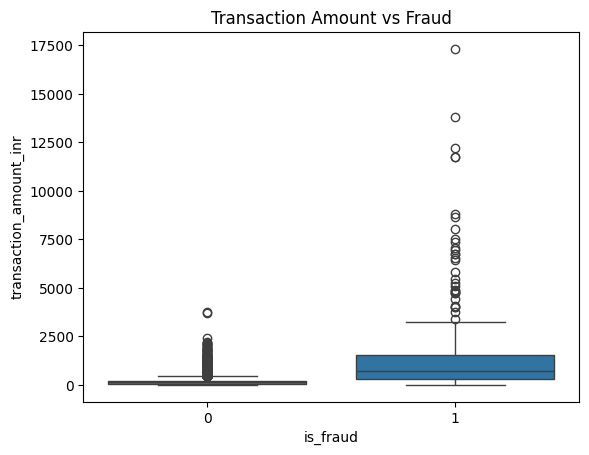

In [ ]:
#Transaction Amount Comparison
sns.boxplot(x='is_fraud', y='transaction_amount_inr', data=df_transactions)
plt.title("Transaction Amount vs Fraud")
plt.show()

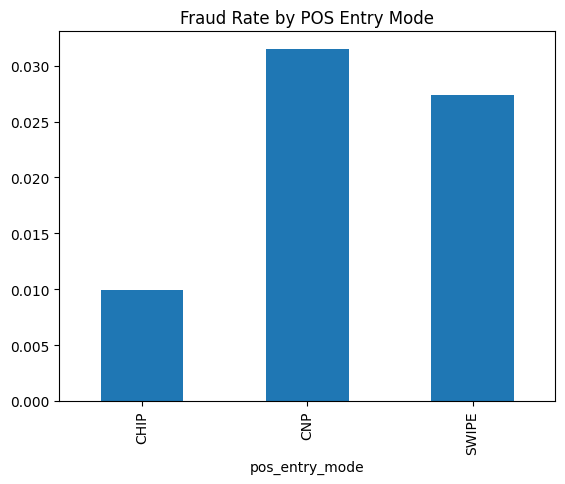

In [ ]:
#POS Entry Mode
fraud_rate_pos = df_transactions.groupby('pos_entry_mode')['is_fraud'].mean()
fraud_rate_pos.plot(kind='bar')
plt.title("Fraud Rate by POS Entry Mode")
plt.show()

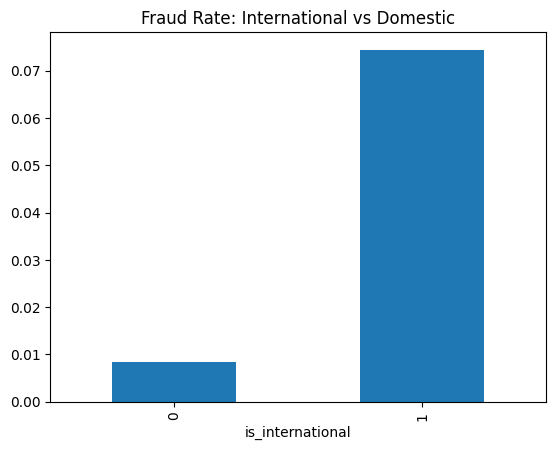

In [ ]:
#International Transactions
fraud_rate_int = df_transactions.groupby('is_international')['is_fraud'].mean()
fraud_rate_int.plot(kind='bar')
plt.title("Fraud Rate: International vs Domestic")
plt.show()

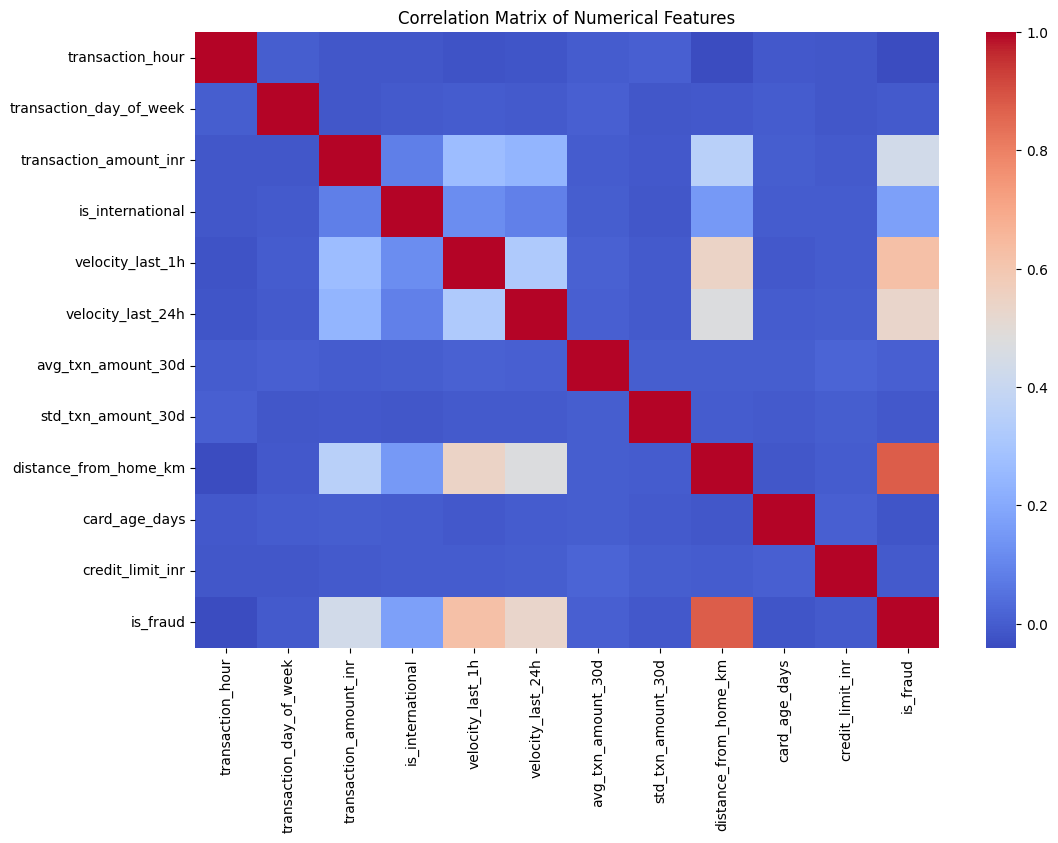

In [ ]:
#Compute Correlation Matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric features
numeric_df = df_transactions.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [ ]:
#duplicates
df_transactions.duplicated().sum()

np.int64(0)

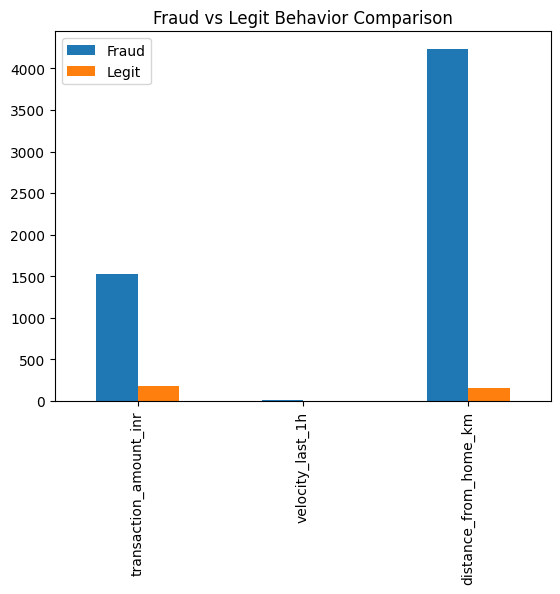

In [ ]:
#Fraud Behavior Radar
fraud_mean = df_transactions[df_transactions['is_fraud']==1].mean(numeric_only=True)
legit_mean = df_transactions[df_transactions['is_fraud']==0].mean(numeric_only=True)

selected_features = ['transaction_amount_inr', 'velocity_last_1h', 'distance_from_home_km']

df_compare = pd.DataFrame({
    'Fraud': fraud_mean[selected_features],
    'Legit': legit_mean[selected_features]
})

df_compare.plot(kind='bar')
plt.title("Fraud vs Legit Behavior Comparison")
plt.show()

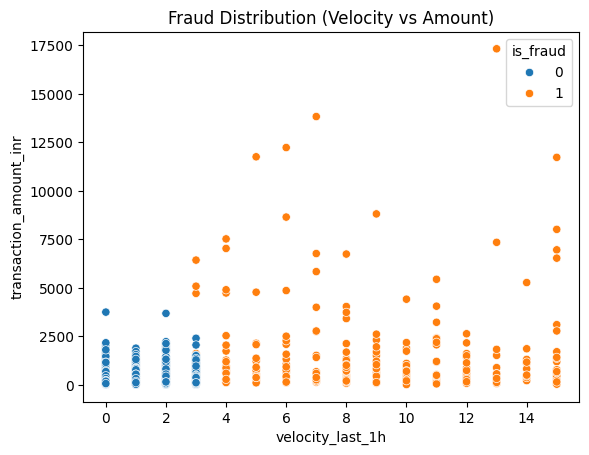

In [ ]:
#Fraud Funnel
sns.scatterplot(
    x='velocity_last_1h',
    y='transaction_amount_inr',
    hue='is_fraud',
    data=df_transactions
)
plt.title("Fraud Distribution (Velocity vs Amount)")
plt.show()

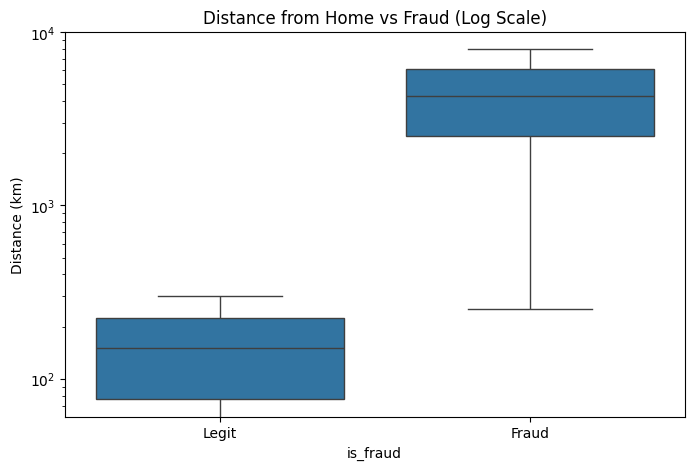

In [ ]:
#Distance vs Fraud
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='distance_from_home_km',
    data=df_transactions
)

plt.yscale('log')  # IMPORTANT for outliers
plt.xticks([0,1], ['Legit', 'Fraud'])
plt.title("Distance from Home vs Fraud (Log Scale)")
plt.ylabel("Distance (km)")
plt.show()

/tmp/ipykernel_1138/2906516678.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_risk.values * 100, y=category_risk.index, palette='flare')


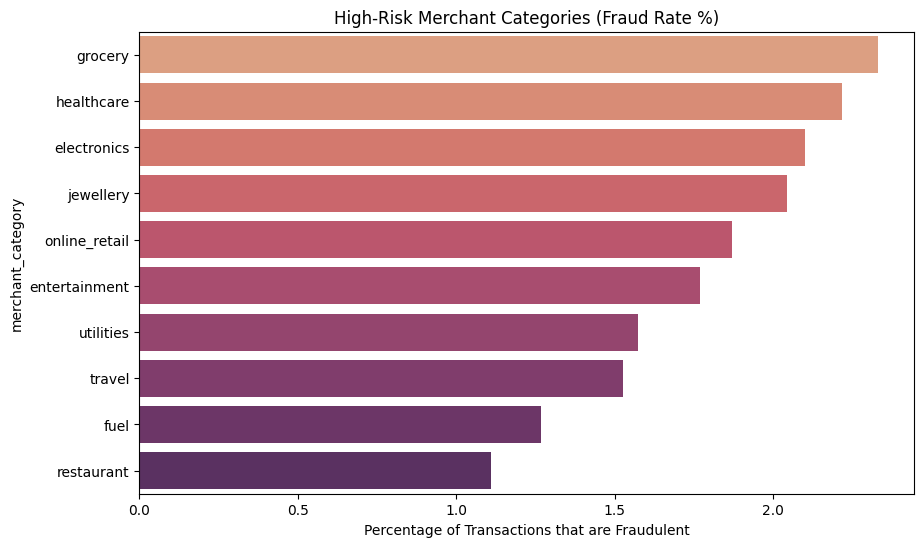

In [ ]:
# UNIQUE STEP: Calculate Risk Weight per Category
category_risk = df_transactions.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=category_risk.values * 100, y=category_risk.index, palette='flare')
plt.title("High-Risk Merchant Categories (Fraud Rate %)")
plt.xlabel("Percentage of Transactions that are Fraudulent")
plt.show()

**FEATURE ENGINEERING AND PREPROCESSING**

In [ ]:
#Feature Engg
#1 Ratio features(Fraud = unusual spending behaviour)
# Amount vs credit limit
df_transactions['amount_to_limit_ratio'] = df_transactions['transaction_amount_inr'] / df_transactions['credit_limit_inr']

# Amount vs user's usual spending
df_transactions['amount_vs_avg_ratio'] = df_transactions['transaction_amount_inr'] / (df_transactions['avg_txn_amount_30d'] + 1)

# Amount vs variability
df_transactions['amount_std_ratio'] = df_transactions['transaction_amount_inr'] / (df_transactions['std_txn_amount_30d'] + 1)

In [ ]:
#velocity intelligence(Fraud = burst activity)
# Short-term vs long-term activity
df_transactions['velocity_ratio'] = df_transactions['velocity_last_1h'] / (df_transactions['velocity_last_24h'] + 1)

# High velocity flag
df_transactions['high_velocity'] = (df_transactions['velocity_last_1h'] > 5).astype(int)

In [ ]:
#behavioural flags
# Night transactions
df_transactions['is_night'] = df_transactions['transaction_hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)

# Weekend transactions
df_transactions['is_weekend'] = df_transactions['transaction_day_of_week'].isin([5, 6]).astype(int)

In [ ]:
#location feature
# Far from home
df_transactions['high_distance'] = (df_transactions['distance_from_home_km'] > 200).astype(int)

In [ ]:
#interaction fetaure
# International + high amount
df_transactions['intl_high_amt'] = df_transactions['is_international'] * df_transactions['amount_to_limit_ratio']

In [ ]:
#Dropping irrelevant columns(irrelevant predictions)
columns_to_drop = [
    'transaction_id',
    'cardholder_id',
    'merchant_id'
]
# Filter columns that actually exist in the DataFrame
existing_columns_to_drop = [col for col in columns_to_drop if col in df_transactions.columns]
df_transactions.drop(existing_columns_to_drop, axis=1, inplace=True)

In [ ]:
#Encoding
df_transactions = pd.get_dummies(
    df_transactions,
    columns=[
        'merchant_category',
        'pos_entry_mode',
        'country_code'
    ],
    drop_first=True
)

In [ ]:
df_transactions.head()

,transaction_timestamp,transaction_hour,transaction_day_of_week,transaction_amount_inr,is_international,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,...,pos_entry_mode_SWIPE,country_code_AU,country_code_CA,country_code_DE,country_code_FR,country_code_GB,country_code_IN,country_code_JP,country_code_SG,country_code_US
0,2023-10-28 08:59:47,8,5,291.07,0,2,2,67.88,385.43,178.6,...,False,False,False,False,False,False,True,False,False,False
1,2023-09-08 23:56:49,23,4,221.33,0,3,4,49.88,322.25,184.1,...,True,False,False,False,False,False,True,False,False,False
2,2023-09-26 21:01:05,21,1,231.06,0,3,2,31.52,369.70,127.6,...,False,False,False,False,False,False,True,False,False,False
3,2023-04-11 23:06:34,23,1,211.16,0,1,1,134.10,376.04,196.4,...,False,False,False,False,False,False,True,False,False,False
4,2023-09-20 19:31:44,19,2,139.86,0,3,2,119.01,132.11,43.6,...,False,False,False,False,False,False,True,False,False,False


**XG BOOST ALGORITHM**

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

**Prepare data forr modeling**

In [ ]:
# List all features that are potentially leaking information due to aggregation over time
# These are the original features and the engineered features that rely on them.
leaky_features_to_drop = [
    'velocity_last_1h',
    'velocity_last_24h',
    'avg_txn_amount_30d',
    'std_txn_amount_30d',
    'amount_vs_avg_ratio',
    'amount_std_ratio',
    'velocity_ratio',
    'high_velocity',
    'intl_high_amt'
]

# NOTE: For demonstration purposes, we are *not* dropping leaky features from X here.
# This will show the inflated performance due to leakage.
X = df_transactions.drop(
    ['is_fraud', 'transaction_timestamp'], # Now only dropping target and timestamp, NOT leaky features
    axis=1,
    errors='ignore'
)
y = df_transactions['is_fraud']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape (with leaky features): {X_train.shape}")
print(f"X_test shape (with leaky features): {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape (with leaky features): (10500, 40)
X_test shape (with leaky features): (4500, 40)
y_train shape: (10500,)
y_test shape: (4500,)


**Train XG Boost classifier**

In [ ]:
# Initialize XGBoost Classifier
# Using `scale_pos_weight` to handle class imbalance
xgb_model = XGBClassifier(objective='binary:logistic',
                          eval_metric='logloss',
                          use_label_encoder=False,
                          random_state=42,
                          scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum())

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**Make Predictions**

In [ ]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC Score: 1.0000


**perform cross validation**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Define the number of folds for cross-validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

print(f"Starting {n_splits}-Fold Stratified Cross-Validation...")

for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{n_splits} ---")
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Calculate scale_pos_weight for the current fold's training data
    # This handles the class imbalance within each fold
    pos_weight = (len(y_train_fold) - y_train_fold.sum()) / y_train_fold.sum()

    # Initialize a new XGBoost Classifier for each fold
    xgb_cv_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False, # Deprecated in newer XGBoost versions, setting to False
        random_state=42,
        scale_pos_weight=pos_weight
    )

    # Train the model
    xgb_cv_model.fit(X_train_fold, y_train_fold)

    # Make predictions
    y_pred_fold = xgb_cv_model.predict(X_val_fold)
    y_pred_proba_fold = xgb_cv_model.predict_proba(X_val_fold)[:, 1]

    # Calculate metrics and store them
    accuracy_scores.append(accuracy_score(y_val_fold, y_pred_fold))
    precision_scores.append(precision_score(y_val_fold, y_pred_fold))
    recall_scores.append(recall_score(y_val_fold, y_pred_fold))
    f1_scores.append(f1_score(y_val_fold, y_pred_fold))
    roc_auc_scores.append(roc_auc_score(y_val_fold, y_pred_proba_fold))

    print(f"  Accuracy: {accuracy_scores[-1]:.4f}")
    print(f"  Precision: {precision_scores[-1]:.4f}")
    print(f"  Recall: {recall_scores[-1]:.4f}")
    print(f"  F1-Score: {f1_scores[-1]:.4f}")
    print(f"  ROC AUC Score: {roc_auc_scores[-1]:.4f}")

print("\n--- Cross-Validation Results (Average across folds) ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")
print(f"Average ROC AUC Score: {np.mean(roc_auc_scores):.4f} (+/- {np.std(roc_auc_scores):.4f})")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Starting 5-Fold Stratified Cross-Validation...

--- Fold 1/5 ---
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC AUC Score: 1.0000

--- Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.9993
  Precision: 0.9811
  Recall: 0.9811
  F1-Score: 0.9811
  ROC AUC Score: 1.0000

--- Fold 3/5 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.9997
  Precision: 0.9815
  Recall: 1.0000
  F1-Score: 0.9907
  ROC AUC Score: 1.0000

--- Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.9997
  Precision: 1.0000
  Recall: 0.9815
  F1-Score: 0.9907
  ROC AUC Score: 1.0000

--- Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.9993
  Precision: 1.0000
  Recall: 0.9630
  F1-Score: 0.9811
  ROC AUC Score: 1.0000

--- Cross-Validation Results (Average across folds) ---
Average Accuracy: 0.9996 (+/- 0.0002)
Average Precision: 0.9925 (+/- 0.0092)
Average Recall: 0.9851 (+/- 0.0139)
Average F1-Score: 0.9887 (+/- 0.0071)
Average ROC AUC Score: 1.0000 (+/- 0.0000)


### Hyperparameter tuning using optuna

In [ ]:
# Install (if needed)
!pip install optuna

import optuna
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt


def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'random_state': 42,

        # Reduced + safer search space
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.3),

        # Regularization (IMPORTANT)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

        # Class imbalance
        'scale_pos_weight': (len(y_train) - y_train.sum()) / y_train.sum()
    }

    model = XGBClassifier(**param)

    #  CROSS VALIDATION (NO TEST LEAKAGE)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='roc_auc'
    )

    return scores.mean()



study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

print("Best trial:")
print(f"ROC-AUC: {study.best_trial.value:.4f}")
print("Best params:")
for key, value in study.best_trial.params.items():
    print(f"{key}: {value}")


#  TRAIN FINAL MODEL

best_params = study.best_params

# Add imbalance weight again
best_params['scale_pos_weight'] = (len(y_train) - y_train.sum()) / y_train.sum()

final_xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    **best_params
)

final_xgb_model.fit(X_train, y_train)

print("\nFinal model trained!")



#  EVALUATION ON TEST SET (NOW CORRECT)

y_pred = final_xgb_model.predict(X_test)
y_pred_proba = final_xgb_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

FPR = FP / (FP + TN)

print("\n--- Final Model Performance ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"FPR: {FPR:.4f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.4 MB/s eta 0:00:00


[I 2026-04-09 16:46:35,041] A new study created in memory with name: no-name-a061312d-3726-4cf5-a8f8-95829f74a843
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:46:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are n

Best trial:
ROC-AUC: 1.0000
Best params:
n_estimators: 281
learning_rate: 0.1374855388588231
max_depth: 4
subsample: 0.9593017898588253
colsample_bytree: 0.7462194331202591
gamma: 0.2889598319668173
reg_lambda: 0.1540737582962677
reg_alpha: 0.0217689532590594

Final model trained!

--- Final Model Performance ---
Accuracy: 0.9998
Precision: 1.0000
Recall: 0.9875
F1 Score: 0.9937
ROC-AUC: 1.0000
FPR: 0.0000


### AUC ROC Curve

<Figure size 800x600 with 0 Axes>

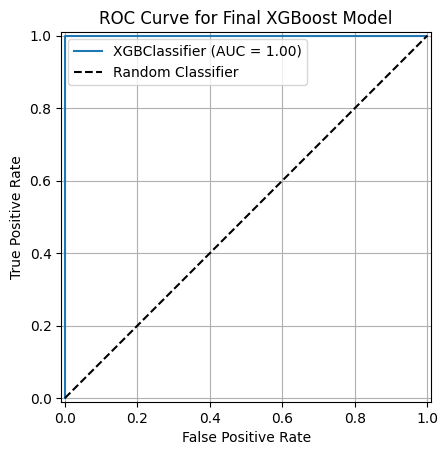

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Plot the ROC AUC Curve
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(final_xgb_model, X_test, y_test)
plt.title('ROC Curve for Final XGBoost Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# 1. Load the test dataset
try:
    df_test = pd.read_csv('test_transactions.csv')
except FileNotFoundError:
    print("test_transactions.csv not found in the current directory. Trying /content/sample_data...")
    try:
        df_test = pd.read_csv('/content/test_transactions.csv')
    except FileNotFoundError:
        print("test_transactions.csv not found in /content/sample_data either. Please provide the correct path.")
        df_test = None

if df_test is not None:
    print("\n--- First 5 rows of test_transactions.csv ---")
    display(df_test.head())
    print("\n--- DataFrame Info for test_transactions.csv ---")
    df_test.info()

    # Store transaction_id for later use to associate predictions
    test_transaction_ids = df_test['transaction_id']

    # 2. Apply the same preprocessing steps as the training data
    # 2.1 Feature Engineering (replicate steps from 9a66af24, 8BMkpL32o93z, HLtwfmw1pXCW, 19U9AuNDpmaO, ta8gMaF7tRMR)
    df_test['amount_to_limit_ratio'] = df_test['transaction_amount_inr'] / df_test['credit_limit_inr']
    df_test['amount_vs_avg_ratio'] = df_test['transaction_amount_inr'] / (df_test['avg_txn_amount_30d'] + 1)
    df_test['amount_std_ratio'] = df_test['transaction_amount_inr'] / (df_test['std_txn_amount_30d'] + 1)
    df_test['velocity_ratio'] = df_test['velocity_last_1h'] / (df_test['velocity_last_24h'] + 1)
    df_test['high_velocity'] = (df_test['velocity_last_1h'] > 5).astype(int)
    df_test['is_night'] = df_test['transaction_hour'].isin([22, 23, 0, 1, 2, 3]).astype(int)
    df_test['is_weekend'] = df_test['transaction_day_of_week'].isin([5, 6]).astype(int)
    df_test['high_distance'] = (df_test['distance_from_home_km'] > 200).astype(int)
    df_test['intl_high_amt'] = df_test['is_international'] * df_test['amount_to_limit_ratio']

    # 2.2 Drop irrelevant columns (replicate steps from 3a51e8e7 and those implicitly dropped for X)
    columns_to_drop_for_prediction = [
        'transaction_id',
        'cardholder_id',
        'merchant_id',
        'transaction_timestamp' # 'transaction_timestamp' was dropped when creating X
    ]
    existing_cols_to_drop = [col for col in columns_to_drop_for_prediction if col in df_test.columns]
    df_test_processed = df_test.drop(existing_cols_to_drop, axis=1, inplace=False)

    # 2.3 One-Hot Encoding (replicate steps from Ps-UwPXA25QG)
    categorical_cols_to_encode = ['merchant_category', 'pos_entry_mode', 'country_code']
    df_test_processed = pd.get_dummies(df_test_processed, columns=categorical_cols_to_encode, drop_first=True)

    # 2.4 Align columns with the training data (X)
    # This is crucial to ensure the test set has the exact same columns in the same order as the training set.
    training_columns = X.columns # X is the DataFrame used for training features

    # Add missing columns (present in X but not in df_test_processed) and fill with 0
    missing_cols = set(training_columns) - set(df_test_processed.columns)
    for c in missing_cols:
        df_test_processed[c] = 0

    # Drop extra columns (present in df_test_processed but not in X)
    extra_cols = set(df_test_processed.columns) - set(training_columns)
    df_test_processed = df_test_processed.drop(columns=list(extra_cols))

    # Ensure the order of columns is the same as training_columns
    df_test_processed = df_test_processed[training_columns]

    print("\n--- Processed Test Data Head (aligned with training features) ---")
    display(df_test_processed.head())
    print(f"Processed test data shape: {df_test_processed.shape}")
    print(f"Training data (X) shape: {X.shape}") # For comparison, shapes should match

    # 3. Make predictions using the final_xgb_model
    test_predictions = final_xgb_model.predict(df_test_processed)
    test_prediction_probabilities = final_xgb_model.predict_proba(df_test_processed)[:, 1]

    # 4. Display predictions
    results_df = pd.DataFrame({
        'transaction_id': test_transaction_ids,
        'predicted_is_fraud': test_predictions,
        'fraud_probability': test_prediction_probabilities
    })

    print("\n--- Sample Predictions on Test Data ---")
    display(results_df.head())
else:
    print("Test dataset was not loaded successfully. Cannot make predictions.")


--- First 5 rows of test_transactions.csv ---


,transaction_id,cardholder_id,merchant_id,merchant_category,transaction_timestamp,transaction_hour,transaction_day_of_week,transaction_amount_inr,country_code,is_international,pos_entry_mode,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,credit_limit_inr
0,TXN00009742,CH_004355,MER_00552,healthcare,2023-11-09 20:27:35,20,3,36.35,IN,0,CNP,1,2,77.50,160.53,117.0,1037,50000
1,TXN00032431,CH_005022,MER_00617,restaurant,2023-08-20 03:02:16,3,6,319.21,IN,0,CNP,3,8,63.90,525.31,170.8,623,150000
2,TXN00042846,CH_007123,MER_00274,restaurant,2023-07-27 08:07:00,8,3,96.58,IN,0,CHIP,1,1,20.24,549.88,64.7,1542,200000
3,TXN00013177,CH_000233,MER_00376,entertainment,2023-05-11 19:38:11,19,3,176.25,IN,0,CNP,3,5,183.20,647.37,216.6,1755,75000
4,TXN00023706,CH_004787,MER_00704,online_retail,2023-06-21 09:51:41,9,2,245.92,IN,0,CHIP,1,8,82.16,310.63,118.0,161,100000



--- DataFrame Info for test_transactions.csv ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           5000 non-null   object 
 1   cardholder_id            5000 non-null   object 
 2   merchant_id              5000 non-null   object 
 3   merchant_category        5000 non-null   object 
 4   transaction_timestamp    5000 non-null   object 
 5   transaction_hour         5000 non-null   int64  
 6   transaction_day_of_week  5000 non-null   int64  
 7   transaction_amount_inr   5000 non-null   float64
 8   country_code             5000 non-null   object 
 9   is_international         5000 non-null   int64  
 10  pos_entry_mode           5000 non-null   object 
 11  velocity_last_1h         5000 non-null   int64  
 12  velocity_last_24h        5000 non-null   int64  
 13  avg_txn_amount_30d       500

,transaction_hour,transaction_day_of_week,transaction_amount_inr,is_international,velocity_last_1h,velocity_last_24h,avg_txn_amount_30d,std_txn_amount_30d,distance_from_home_km,card_age_days,...,pos_entry_mode_SWIPE,country_code_AU,country_code_CA,country_code_DE,country_code_FR,country_code_GB,country_code_IN,country_code_JP,country_code_SG,country_code_US
0,20,3,36.35,0,1,2,77.50,160.53,117.0,1037,...,False,False,False,False,False,False,True,False,False,False
1,3,6,319.21,0,3,8,63.90,525.31,170.8,623,...,False,False,False,False,False,False,True,False,False,False
2,8,3,96.58,0,1,1,20.24,549.88,64.7,1542,...,False,False,False,False,False,False,True,False,False,False
3,19,3,176.25,0,3,5,183.20,647.37,216.6,1755,...,False,False,False,False,False,False,True,False,False,False
4,9,2,245.92,0,1,8,82.16,310.63,118.0,161,...,False,False,False,False,False,False,True,False,False,False


Processed test data shape: (5000, 40)
Training data (X) shape: (15000, 40)

--- Sample Predictions on Test Data ---


,transaction_id,predicted_is_fraud,fraud_probability
0,TXN00009742,0,0.000047
1,TXN00032431,0,0.000210
2,TXN00042846,0,0.000047
3,TXN00013177,0,0.000051
4,TXN00023706,0,0.000167


SHAP

In [ ]:
import joblib

# Save model
joblib.dump(final_xgb_model, "best_model.pkl")

# Save processed test data (VERY IMPORTANT)
X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [ ]:
joblib.dump(X.columns.tolist(), "feature_order.pkl")

['feature_order.pkl']

In [ ]:
FEATURE_ORDER = joblib.load("feature_order.pkl")

In [ ]:
import joblib
import numpy as np

# Load model and feature order
model = joblib.load("/content/best_model.pkl")
FEATURE_ORDER = joblib.load("/content/feature_order.pkl")


# Prepare features
def prepare_features(input_data):
    features = []

    for feature in FEATURE_ORDER:
        if feature in input_data:
            features.append(input_data[feature])
        else:
            features.append(0)

    return features


# Risk Engine
def risk_engine(probability):

    risk_score = int(probability * 100)

    if probability < 0.3:
        risk_level = "LOW"
        action = "APPROVE TRANSACTION"

    elif probability < 0.7:
        risk_level = "MEDIUM"
        action = "CUSTOMER CONFIRMATION REQUIRED"

    else:
        risk_level = "HIGH"
        action = "BLOCK TRANSACTION & ALERT FRAUD ANALYST"

    return risk_score, risk_level, action


# Alert system (optional)
def generate_alert(risk_level):

    if risk_level == "HIGH":
        return "🚨 FRAUD ALERT GENERATED"

    elif risk_level == "MEDIUM":
        return "⚠️ SUSPICIOUS TRANSACTION - VERIFY CUSTOMER"

    else:
        return "✅ TRANSACTION SAFE"


# Final prediction function
def predict_transaction(input_data):

    features = prepare_features(input_data)
    features = np.array(features).reshape(1, -1)

    probability = model.predict_proba(features)[0][1]

    risk_score, risk_level, action = risk_engine(probability)

    alert = generate_alert(risk_level)

    return {
        "fraud_probability": float(probability),
        "risk_score": risk_score,
        "risk_level": risk_level,
        "recommended_action": action,
        "alert": alert
    }

In [ ]:
sample = {
    "transaction_amount": 50000,
    "velocity_last_1h": 4,
    "distance_from_home_km": 800
}
print(predict_transaction(sample))

{'fraud_probability': 0.9821680784225464, 'risk_score': 98, 'risk_level': 'HIGH', 'recommended_action': 'BLOCK TRANSACTION & ALERT FRAUD ANALYST', 'alert': '🚨 FRAUD ALERT GENERATED'}
